# Airline Passenger Satisfaction
### About Dataset
Passenger reviews of airlines, Airline Passenger Satisfaction
### Information about Columns:
**ID**: Passenger ID

**Gender**: Passenger gender

**Age**: Passenger age

**Customer Type**: The customer type

**Type of Travel**: Purpose of the flight of the passengers

**Class**: Travel class in the plane of the passengers

**Flight Distance**: Flight distance

**Departure Delay**: Minutes delayed when departure

**Arrival Delay**: Minutes delayed when Arrival

**Departure & Arrival Time Сonvenience**: Convenience of departure and arrival times for passengers

**Ease of Online Booking**: Easy to book

**Check-in Service**: Ease of registration

**Online Boarding**: Convenience of online registration

**Gate Location**: Gate Location Estimation

**On-board Service**: Service on board

**Seat Comfort**: Comfortable seating

**Leg Room Service**: Leg room service level

**Cleanliness**: Cleanliness level

**Food and Drink**: Quality of food and drinks

**In-flight Service**: Level of service on board

**In-flight Wifi Service**: Wifi quality level on board

**In-flight Entertainment**: Rating of in-flight entertainment

**Baggage Handling**: Opinion on baggage handling

**Satisfaction**: Airline satisfaction level

## Importing Basic Libraries and Dataset

In [1]:
## Data Analysis packages
import numpy as np
import pandas as pd

## Data Visualization packages
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import matplotlib
%matplotlib inline
from pylab import rcParams
import missingno as msno

import warnings
warnings.filterwarnings('ignore')

In [2]:
dataset = pd.read_csv('airlines.csv')
pd.set_option('display.max_columns', 100)
dataset.head()

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0


In [3]:
# Copying the dataset to a new dataframe for analysis 
df = dataset.copy()
df.head()

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0


## Data Exploration, Cleaning and Handling

In [4]:
## Initial Statistical description

df.describe()

,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1981.409055,2.838597,2.990645,2.851994,2.990422,3.249130,3.383477,3.519703,3.472105,3.465075,3.485902,3.695673,3.340807,3.705759,3.352587,14.713713,15.091129
std,15.119360,1027.115606,1.392983,1.527224,1.443729,1.305970,1.318818,1.346059,1.306511,1.305560,1.270836,1.292226,1.156483,1.260582,1.151774,1.298715,38.071126,38.465650
min,7.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,1359.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,1925.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,51.000000,2544.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,6951.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


**Observations**

- The average delay in flights are 15 minutes, with a deviation of 38 
- Median of the delays are 0, which means 50% of the flights from this data, were not delayed


In [5]:
## shape of the train dataset
df.shape

(129880, 23)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Gender                             129880 non-null  object 
 2   Customer Type                      129880 non-null  object 
 3   Age                                129880 non-null  int64  
 4   Type of Travel                     129880 non-null  object 
 5   Class                              129880 non-null  object 
 6   Flight Distance                    129880 non-null  int64  
 7   Seat comfort                       129880 non-null  int64  
 8   Departure/Arrival time convenient  129880 non-null  int64  
 9   Food and drink                     129880 non-null  int64  
 10  Gate location                      129880 non-null  int64  
 11  Inflight wifi service              1298

- Only Arrival Delay in Minutes has null values. Lets visualize to see any patterns in the missing values

<Axes: >

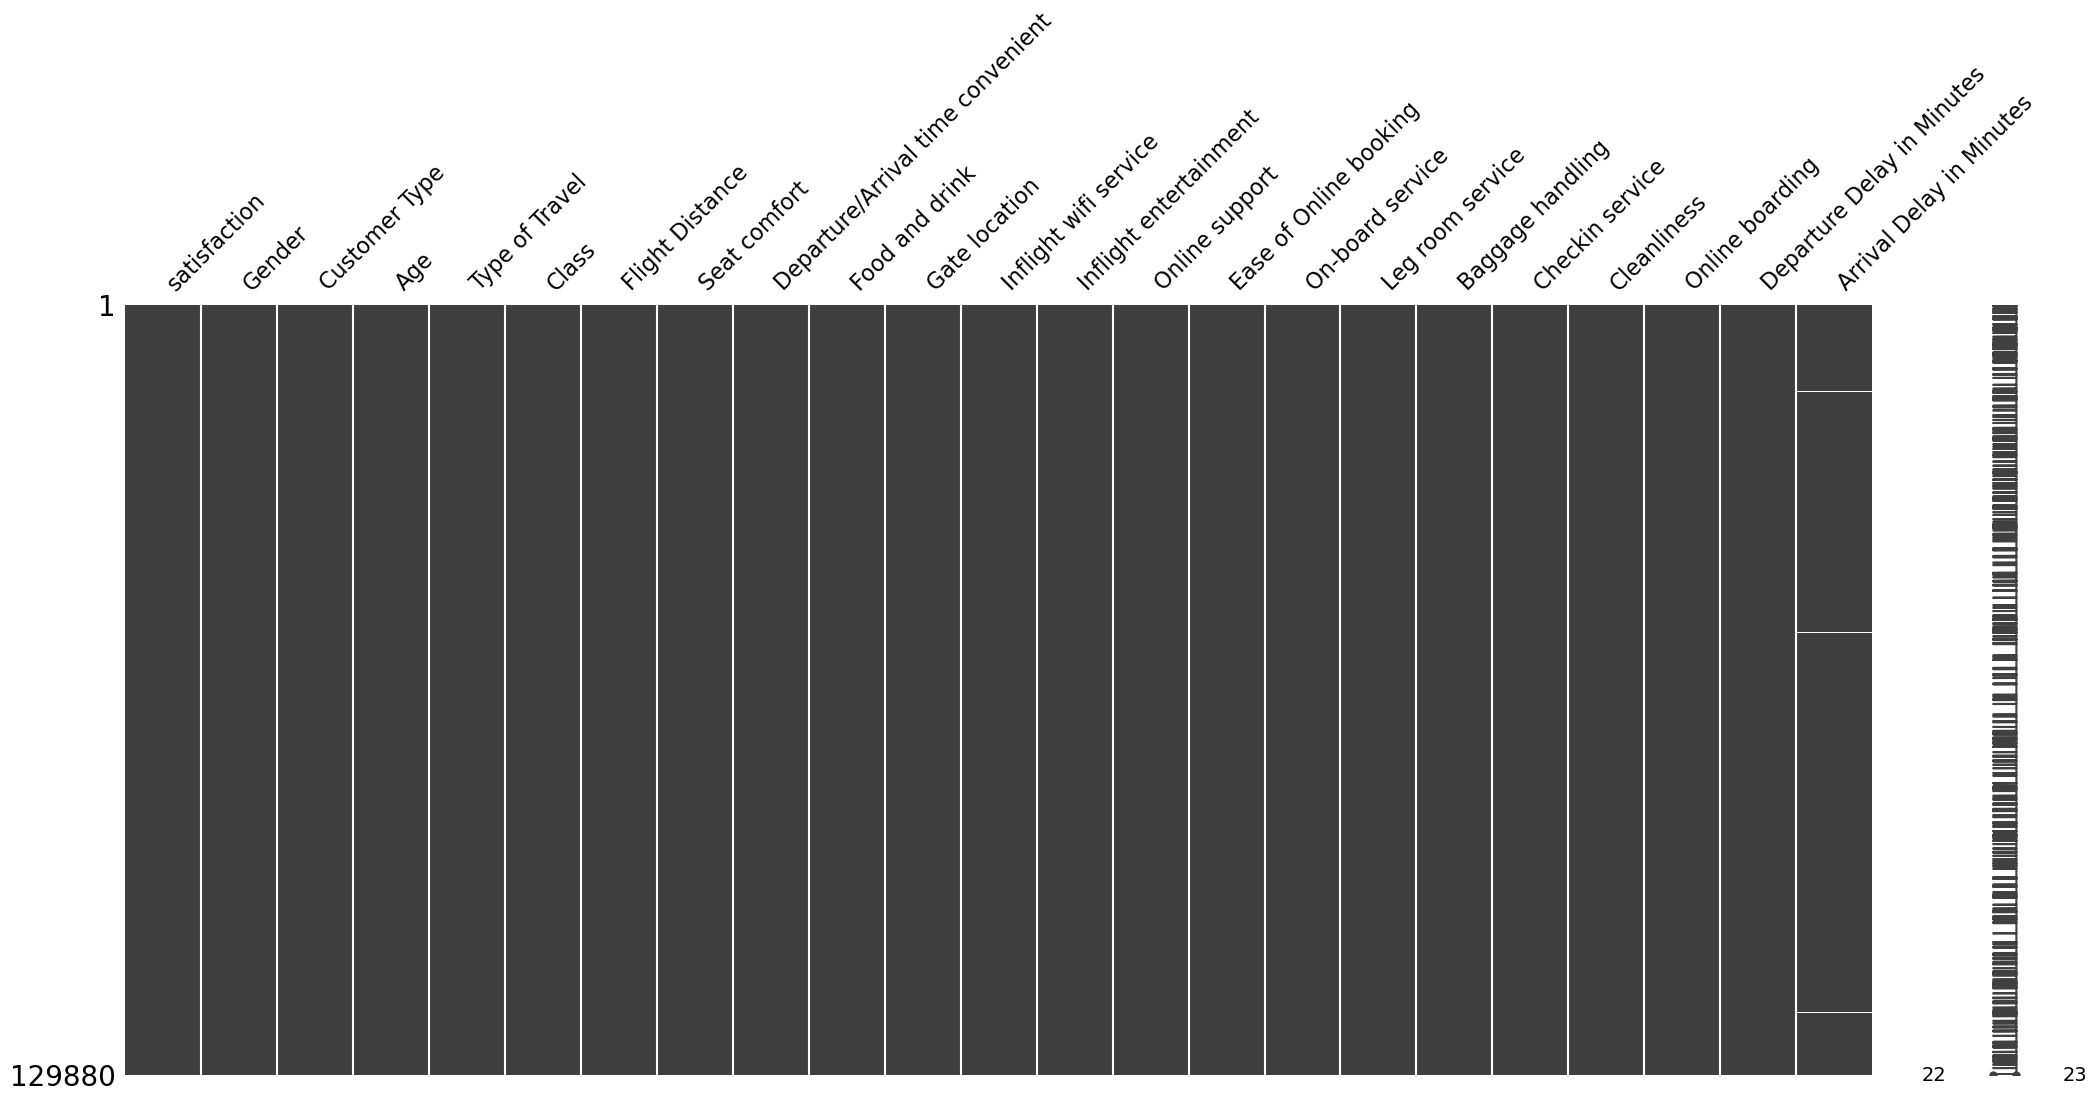

In [7]:
msno.matrix(df)

**Observations**

- There are 129880 rows for 23 features in our data
- In our dataset, all the datatypes belongs to a numeric class that is int, float and object
- only arrival delay in minutes have some null values


In [8]:
# percentage of null values

df.isnull().sum()

satisfaction                           0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

- The number of null values is 310 in "Arrival Delay in Minutes" column
- The percentage of null values is ~ 0.3%

In [9]:
round(df.describe().T, 2)

,count,mean,std,min,25%,50%,75%,max
Age,129880.0,39.43,15.12,7.0,27.0,40.0,51.0,85.0
Flight Distance,129880.0,1981.41,1027.12,50.0,1359.0,1925.0,2544.0,6951.0
Seat comfort,129880.0,2.84,1.39,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,129880.0,2.99,1.53,0.0,2.0,3.0,4.0,5.0
Food and drink,129880.0,2.85,1.44,0.0,2.0,3.0,4.0,5.0
Gate location,129880.0,2.99,1.31,0.0,2.0,3.0,4.0,5.0
Inflight wifi service,129880.0,3.25,1.32,0.0,2.0,3.0,4.0,5.0
Inflight entertainment,129880.0,3.38,1.35,0.0,2.0,4.0,4.0,5.0
Online support,129880.0,3.52,1.31,0.0,3.0,4.0,5.0,5.0
Ease of Online booking,129880.0,3.47,1.31,0.0,2.0,4.0,5.0,5.0


In [10]:
# Duplicate values
df.duplicated().sum() 

0

In [11]:
len(df.satisfaction)

129880

## Analysis and Visualization

In [12]:
df.columns

Index(['satisfaction', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Seat comfort',
       'Departure/Arrival time convenient', 'Food and drink', 'Gate location',
       'Inflight wifi service', 'Inflight entertainment', 'Online support',
       'Ease of Online booking', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes'],
      dtype='object')

In [13]:
df.corr(numeric_only=True)

,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
Age,1.000000,-0.249625,0.008784,0.039055,0.015749,-0.000547,0.013965,0.130511,0.121201,0.071594,0.066704,0.083762,-0.015452,0.031845,-0.018271,0.037973,-0.009041,-0.011248
Flight Distance,-0.249625,1.000000,-0.042409,0.001350,-0.004649,-0.002409,0.012230,-0.027542,-0.032022,-0.022299,-0.032559,-0.030316,0.019768,0.002456,0.009432,0.009604,0.112555,0.110103
Seat comfort,0.008784,-0.042409,1.000000,0.434951,0.715997,0.405300,0.129131,0.426447,0.120278,0.211531,0.121149,0.136136,0.118489,0.041214,0.108475,0.130396,-0.023817,-0.025506
Departure/Arrival time convenient,0.039055,0.001350,0.434951,1.000000,0.527381,0.544259,-0.001974,0.077203,-0.000546,0.001755,0.060446,0.029422,0.067396,0.062794,0.067126,-0.000623,0.004395,0.002599
Food and drink,0.015749,-0.004649,0.715997,0.527381,1.000000,0.523328,0.025917,0.367669,0.028554,0.041189,0.038646,0.074161,0.036370,0.011898,0.033416,0.013587,-0.013433,-0.014881
Gate location,-0.000547,-0.002409,0.405300,0.544259,0.523328,1.000000,-0.004086,-0.000280,0.002908,0.001442,-0.025132,-0.007407,-0.000401,-0.031859,-0.001705,-0.003043,0.003962,0.003640
Inflight wifi service,0.013965,0.012230,0.129131,-0.001974,0.025917,-0.004086,1.000000,0.253823,0.557340,0.601100,0.060794,0.033589,0.038251,0.092508,0.038263,0.631786,-0.032900,-0.035270
Inflight entertainment,0.130511,-0.027542,0.426447,0.077203,0.367669,-0.000280,0.253823,1.000000,0.441957,0.321731,0.183912,0.160731,0.117213,0.224120,0.109451,0.355714,-0.030491,-0.033321
Online support,0.121201,-0.032022,0.120278,-0.000546,0.028554,0.002908,0.557340,0.441957,1.000000,0.617489,0.157930,0.138433,0.102444,0.206824,0.095726,0.669843,-0.034018,-0.036087
Ease of Online booking,0.071594,-0.022299,0.211531,0.001755,0.041189,0.001442,0.601100,0.321731,0.617489,1.000000,0.436264,0.355122,0.398322,0.137744,0.417675,0.684320,-0.036545,-0.039806


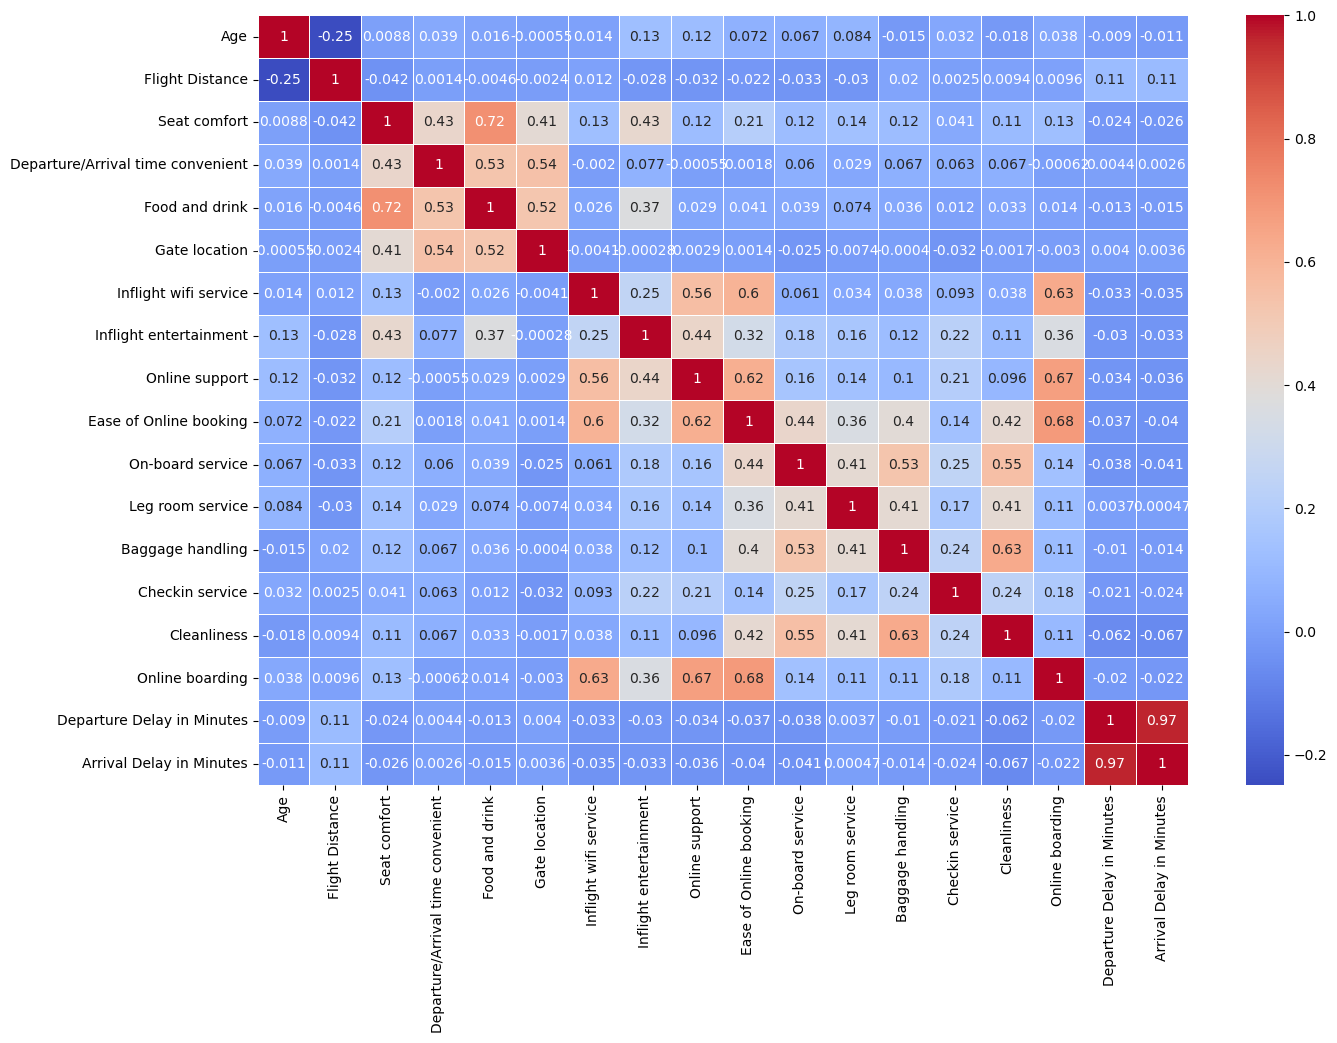

In [14]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

departure delay in minutes and arrival dalay in minutes are highly co-related!

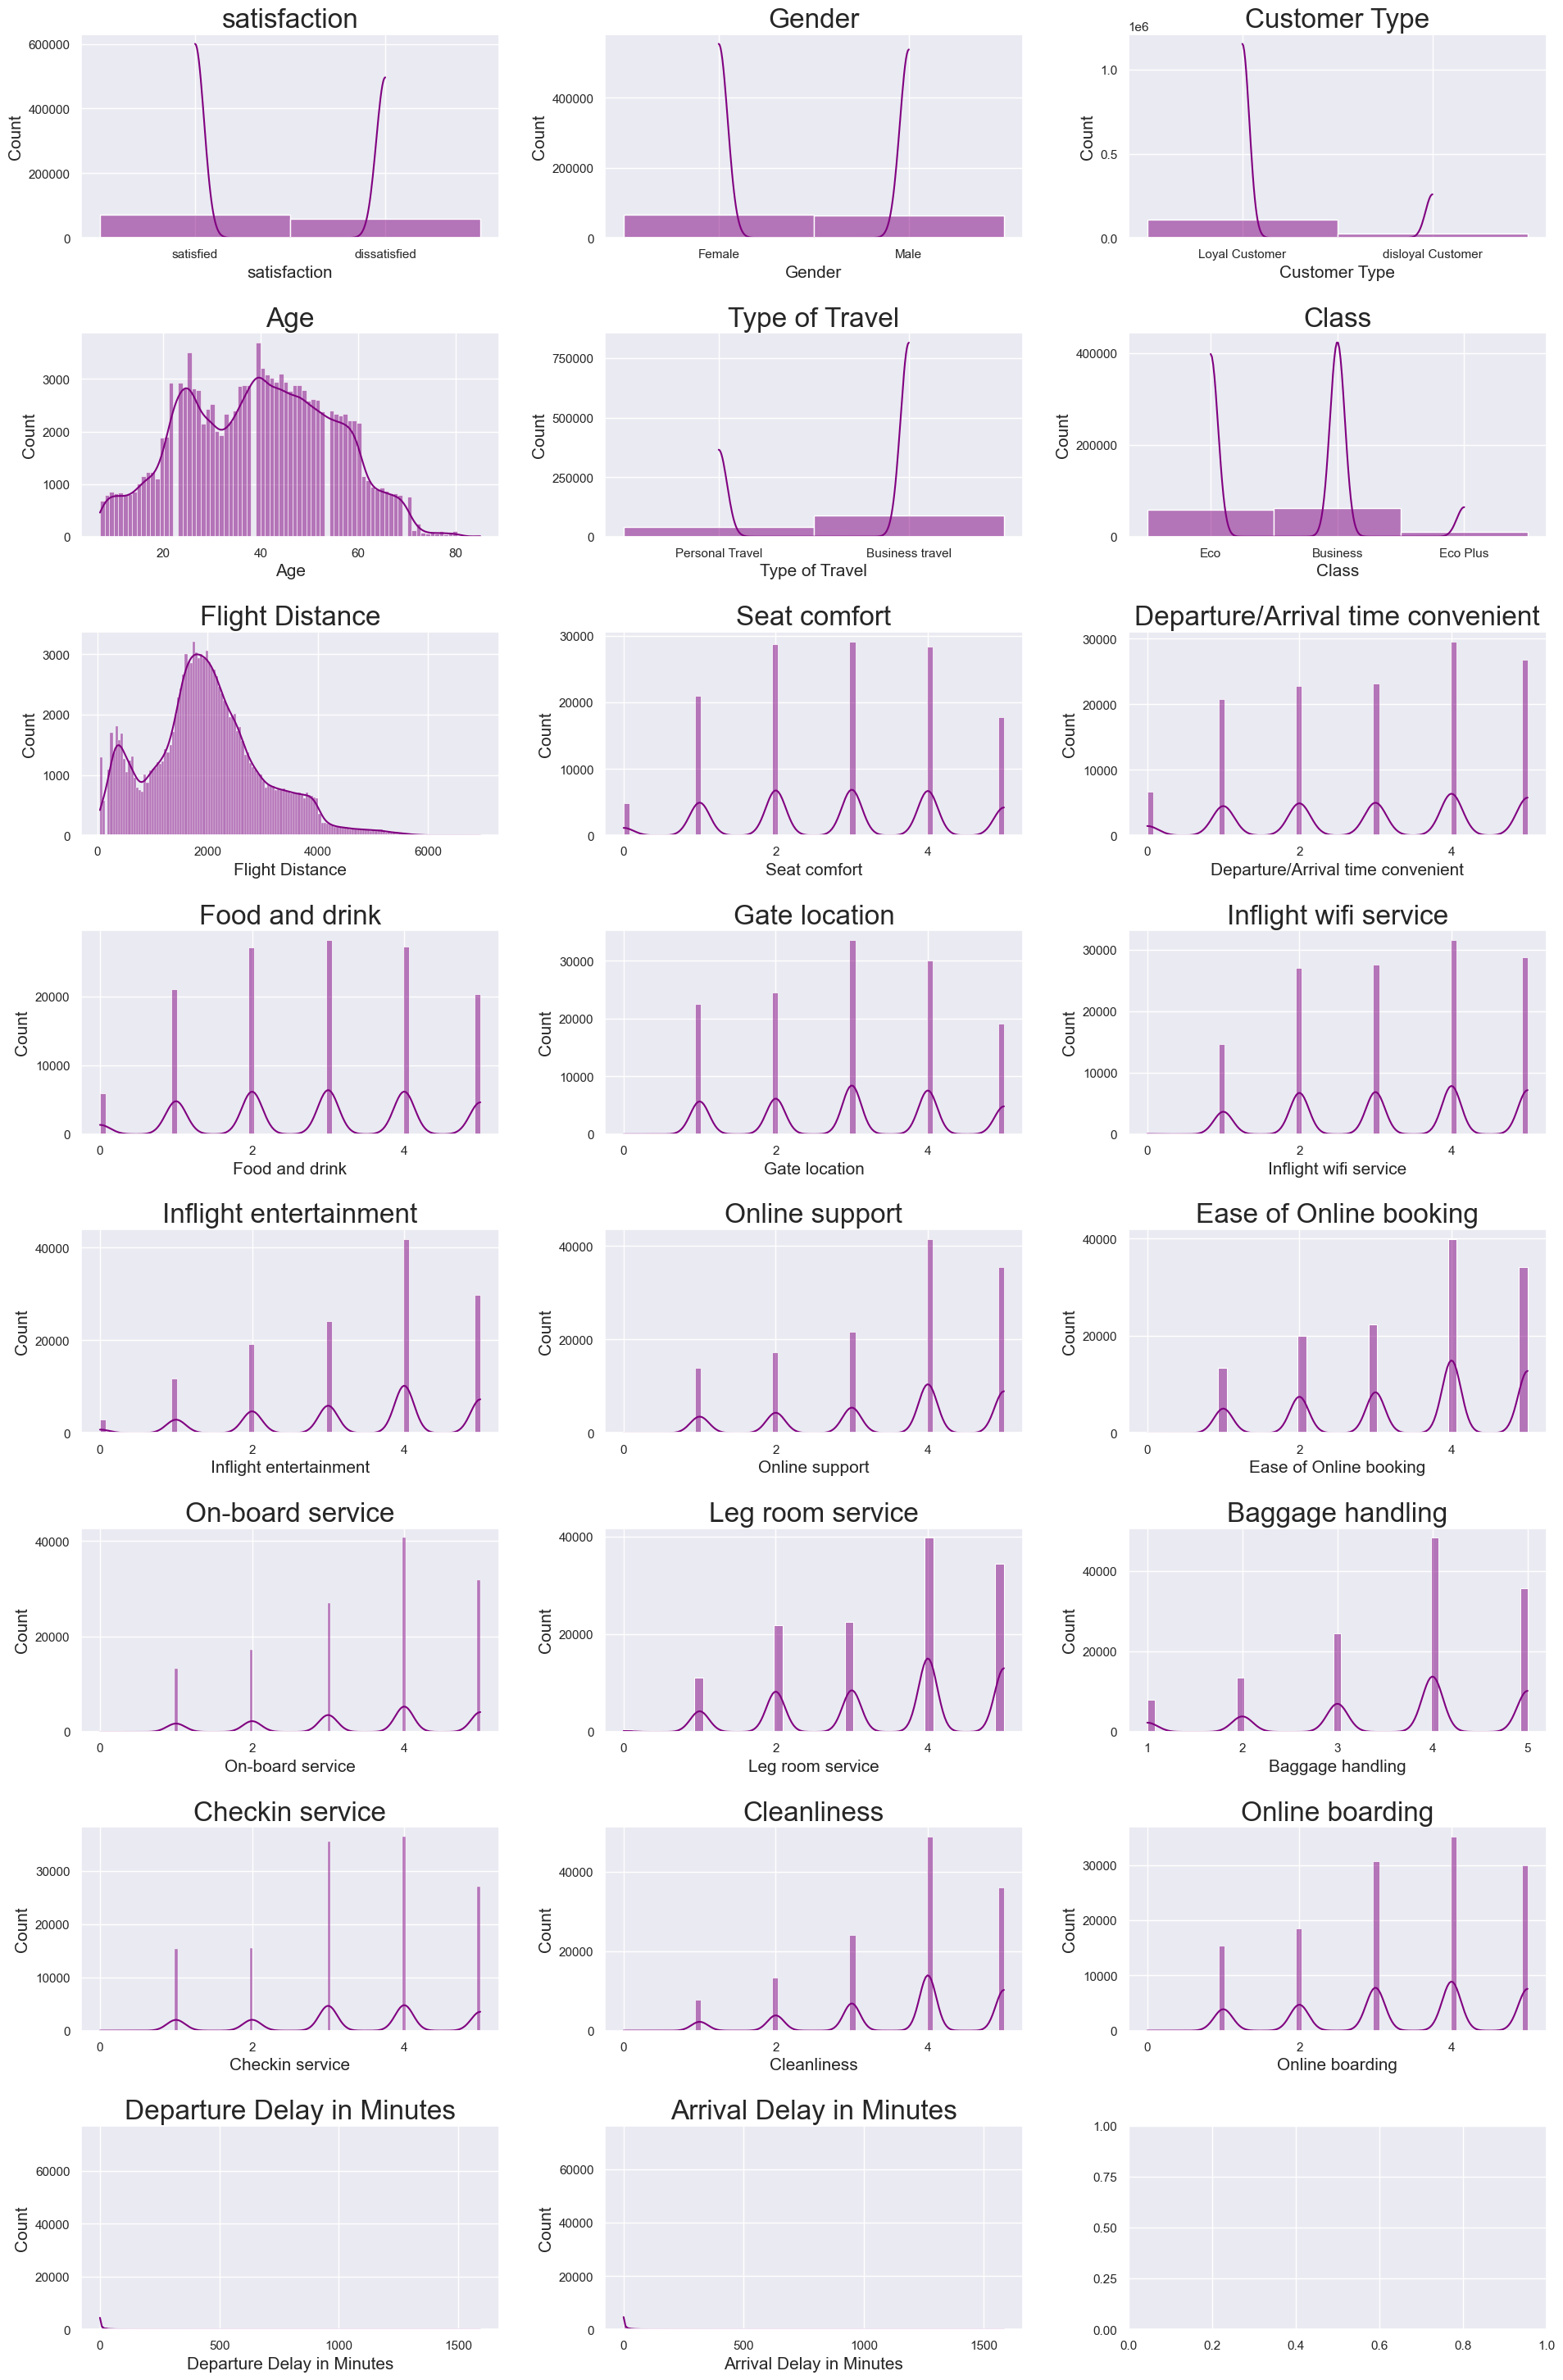

In [15]:
sns.set_theme(rc={
    "font.size":15,
    "axes.titlesize":10,
    "axes.labelsize":15},
    style="darkgrid")
fig, axs = plt.subplots(8, 3, figsize=(20,30))
fig.tight_layout(pad=4.0)

for f, ax in zip(df, axs.ravel()):
    sns.set_theme(font_scale = 2)
    ax = sns.histplot(ax=ax, data=df, x=df[f], kde=True, color='purple')
    ax.set_title(f)



**Observation**
1. Satisfaction

    Majority of passengers are satisfied, but a significant portion is dissatisfied, indicating mixed service experience.

2. Gender

    Distribution is almost equal between male and female passengers.

3. Customer Type

    Loyal customers dominate the dataset compared to disloyal customers.

4. Age

    Most passengers are between 25–55 years, with a peak around 35–45 years.

5. Type of Travel

    Business travel is much more common than personal travel.

6. Class

    Business class and Economy class dominate, while Eco Plus is relatively small.

7. Flight Distance

    Most flights fall in the 1500–2500 distance range, with fewer long-distance flights.

8. Seat Comfort

    Ratings mostly fall between 3–4, indicating generally good seat comfort.

9. Departure/Arrival Time Convenience

    Most ratings are 3–5, meaning passengers generally find timings convenient.

10. Food and Drink

    Ratings concentrate around 3–4, suggesting average to good satisfaction.

11. Gate Location

    Most ratings are 3–4, indicating acceptable gate accessibility.

12. Inflight WiFi Service

    Ratings vary but lean toward 3–4, meaning moderate satisfaction.

13. Inflight Entertainment

    Many ratings are 4–5, suggesting passengers generally like entertainment services.

14. Online Support

    Ratings are mostly 4–5, indicating strong satisfaction with support services.

15. Ease of Online Booking

    Majority ratings are 4–5, showing booking process is user-friendly.

16. On-board Service

    Ratings are mainly 4–5, indicating good onboard staff service.

17. Leg Room Service

    Most ratings are 3–5, showing generally acceptable legroom comfort.

18. Baggage Handling

    Ratings concentrate around 4–5, meaning baggage handling is well rated.

19. Check-in Service

    Most ratings 3–5, reflecting generally smooth check-in experience.

20. Cleanliness

    Ratings mainly 4–5, suggesting high satisfaction with aircraft cleanliness.

21. Online Boarding

    Ratings mostly 3–5, indicating generally convenient boarding process.

22. Departure Delay in Minutes

    Majority of flights show very low departure delays, with few extreme outliers.

23. Arrival Delay in Minutes

    Similar to departure delays, most flights arrive with minimal delay, but there are some large outliers.

### Piechart percentage distribution features

In [16]:
temp_df = df.copy()

In [17]:
temp_df.drop(['Age','Flight Distance','Departure Delay in Minutes', 'Arrival Delay in Minutes','satisfaction'], axis=1, inplace=True)

In [18]:
temp_df.columns

Index(['Gender', 'Customer Type', 'Type of Travel', 'Class', 'Seat comfort',
       'Departure/Arrival time convenient', 'Food and drink', 'Gate location',
       'Inflight wifi service', 'Inflight entertainment', 'Online support',
       'Ease of Online booking', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness',
       'Online boarding'],
      dtype='object')

In [19]:
temp_df.shape

(129880, 18)

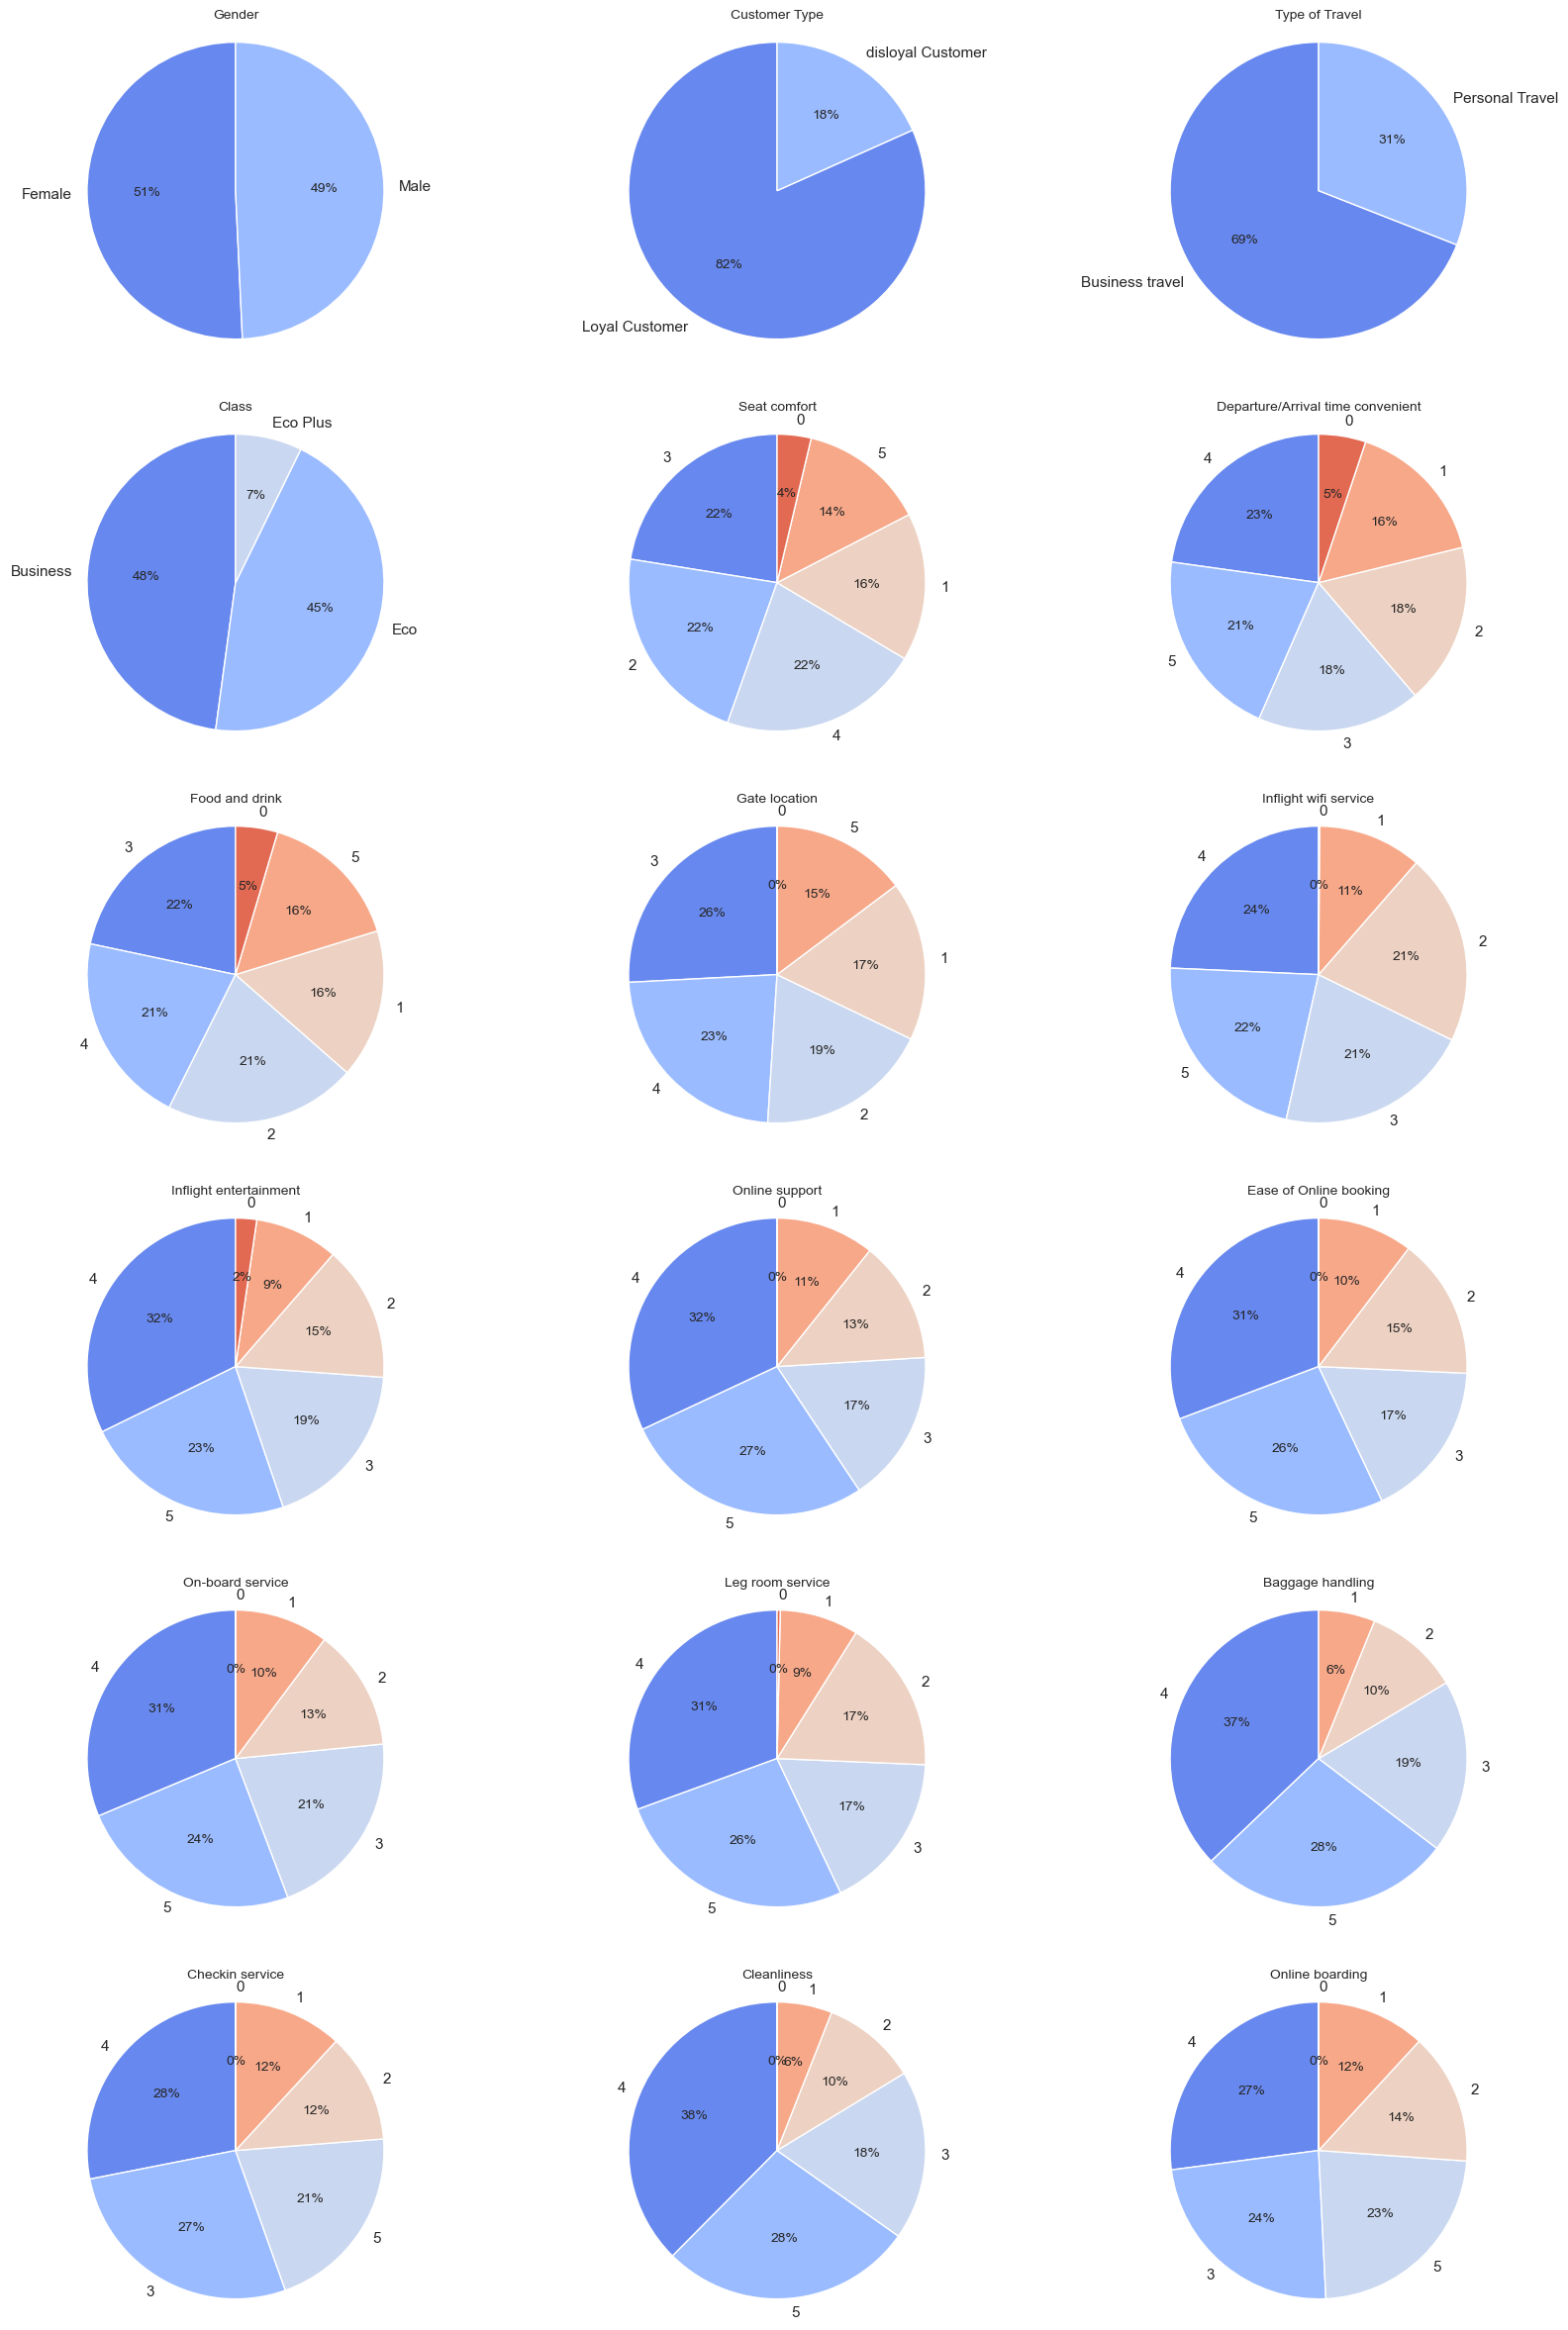

In [20]:
sns.set_theme(rc={
            "font.size":10,
            "axes.titlesize":10,
            "axes.labelsize":13},
             style="darkgrid")
fig, axes = plt.subplots(6, 3, figsize = (20, 30))
for i, col in enumerate(temp_df):
    column_values = temp_df[col].value_counts()
    labels = column_values.index
    sizes = column_values.values
    axes[i//3, i%3].pie(sizes,labels = labels, colors = sns.color_palette("coolwarm"),autopct = '%1.0f%%', startangle = 90)
    axes[i//3, i%3].axis('equal')
    axes[i//3, i%3].set_title(col)
plt.show()

Observations:

- The number of men and women in this sample is approximately the same
- The vast majority of the airline's customers are repeat customers
- Most of the clients flew for business rather than personal reasons
- About half of the passengers were in business class
- More than 60% of passengers were satisfied with the luggage transportation service(rated 4-5 out of 5)
- More than 50% of passengers were comfortable sitting in their seats(rated 4-5 out of 5)

In [21]:
df.satisfaction.value_counts()

satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of Satisfaction')

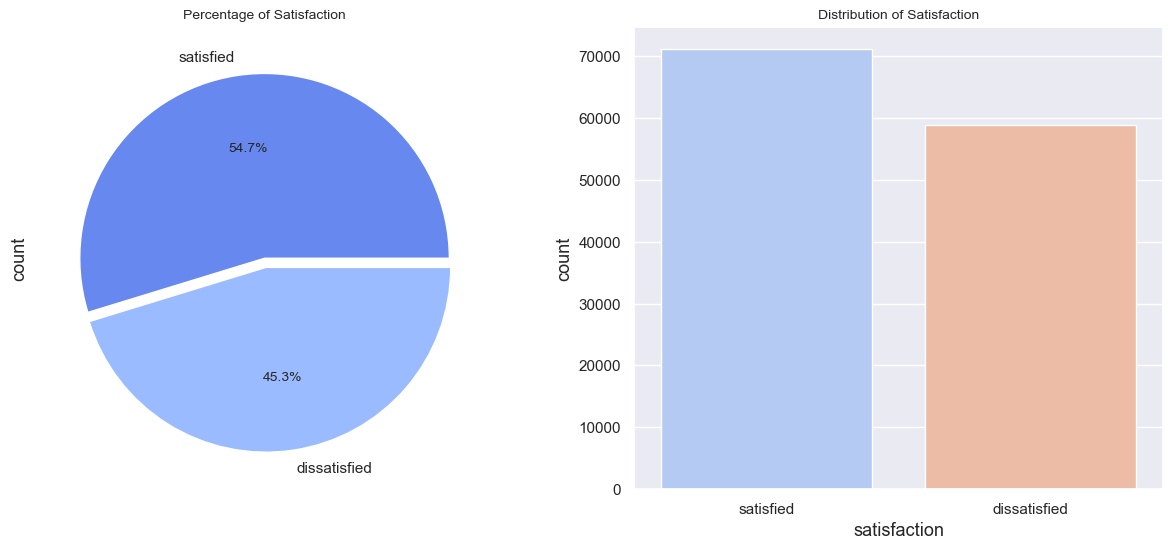

In [22]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(15,6))
df.satisfaction.value_counts().plot.pie(explode=(0, 0.05), colors=sns.color_palette("coolwarm"),autopct='%1.1f%%',ax=ax1)
ax1.set_title("Percentage of Satisfaction")
sns.countplot(x= "satisfaction", data=df, ax=ax2, palette='coolwarm')
ax2.set_title("Distribution of Satisfaction")

**Observation**:

- As per the given data, 56.7% people are dissatisfied and neutral
- And 43.3 people are satisfied


In [23]:
# numerical and categorical features
numerical_cols = df.select_dtypes(include=np.number).columns.to_list()
categorical_cols = df.select_dtypes('object').columns.to_list()

In [24]:
#numerical columns
print("Total number of columns are:",len(numerical_cols))
print(numerical_cols)

Total number of columns are: 18
['Age', 'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Gate location', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


In [25]:
#Categorical Columns
print("Total number of columns are:",len(categorical_cols))
print(categorical_cols)

Total number of columns are: 5
['satisfaction', 'Gender', 'Customer Type', 'Type of Travel', 'Class']


In [26]:
categorical_cols.remove('satisfaction')

## EDA on Numerical Columns

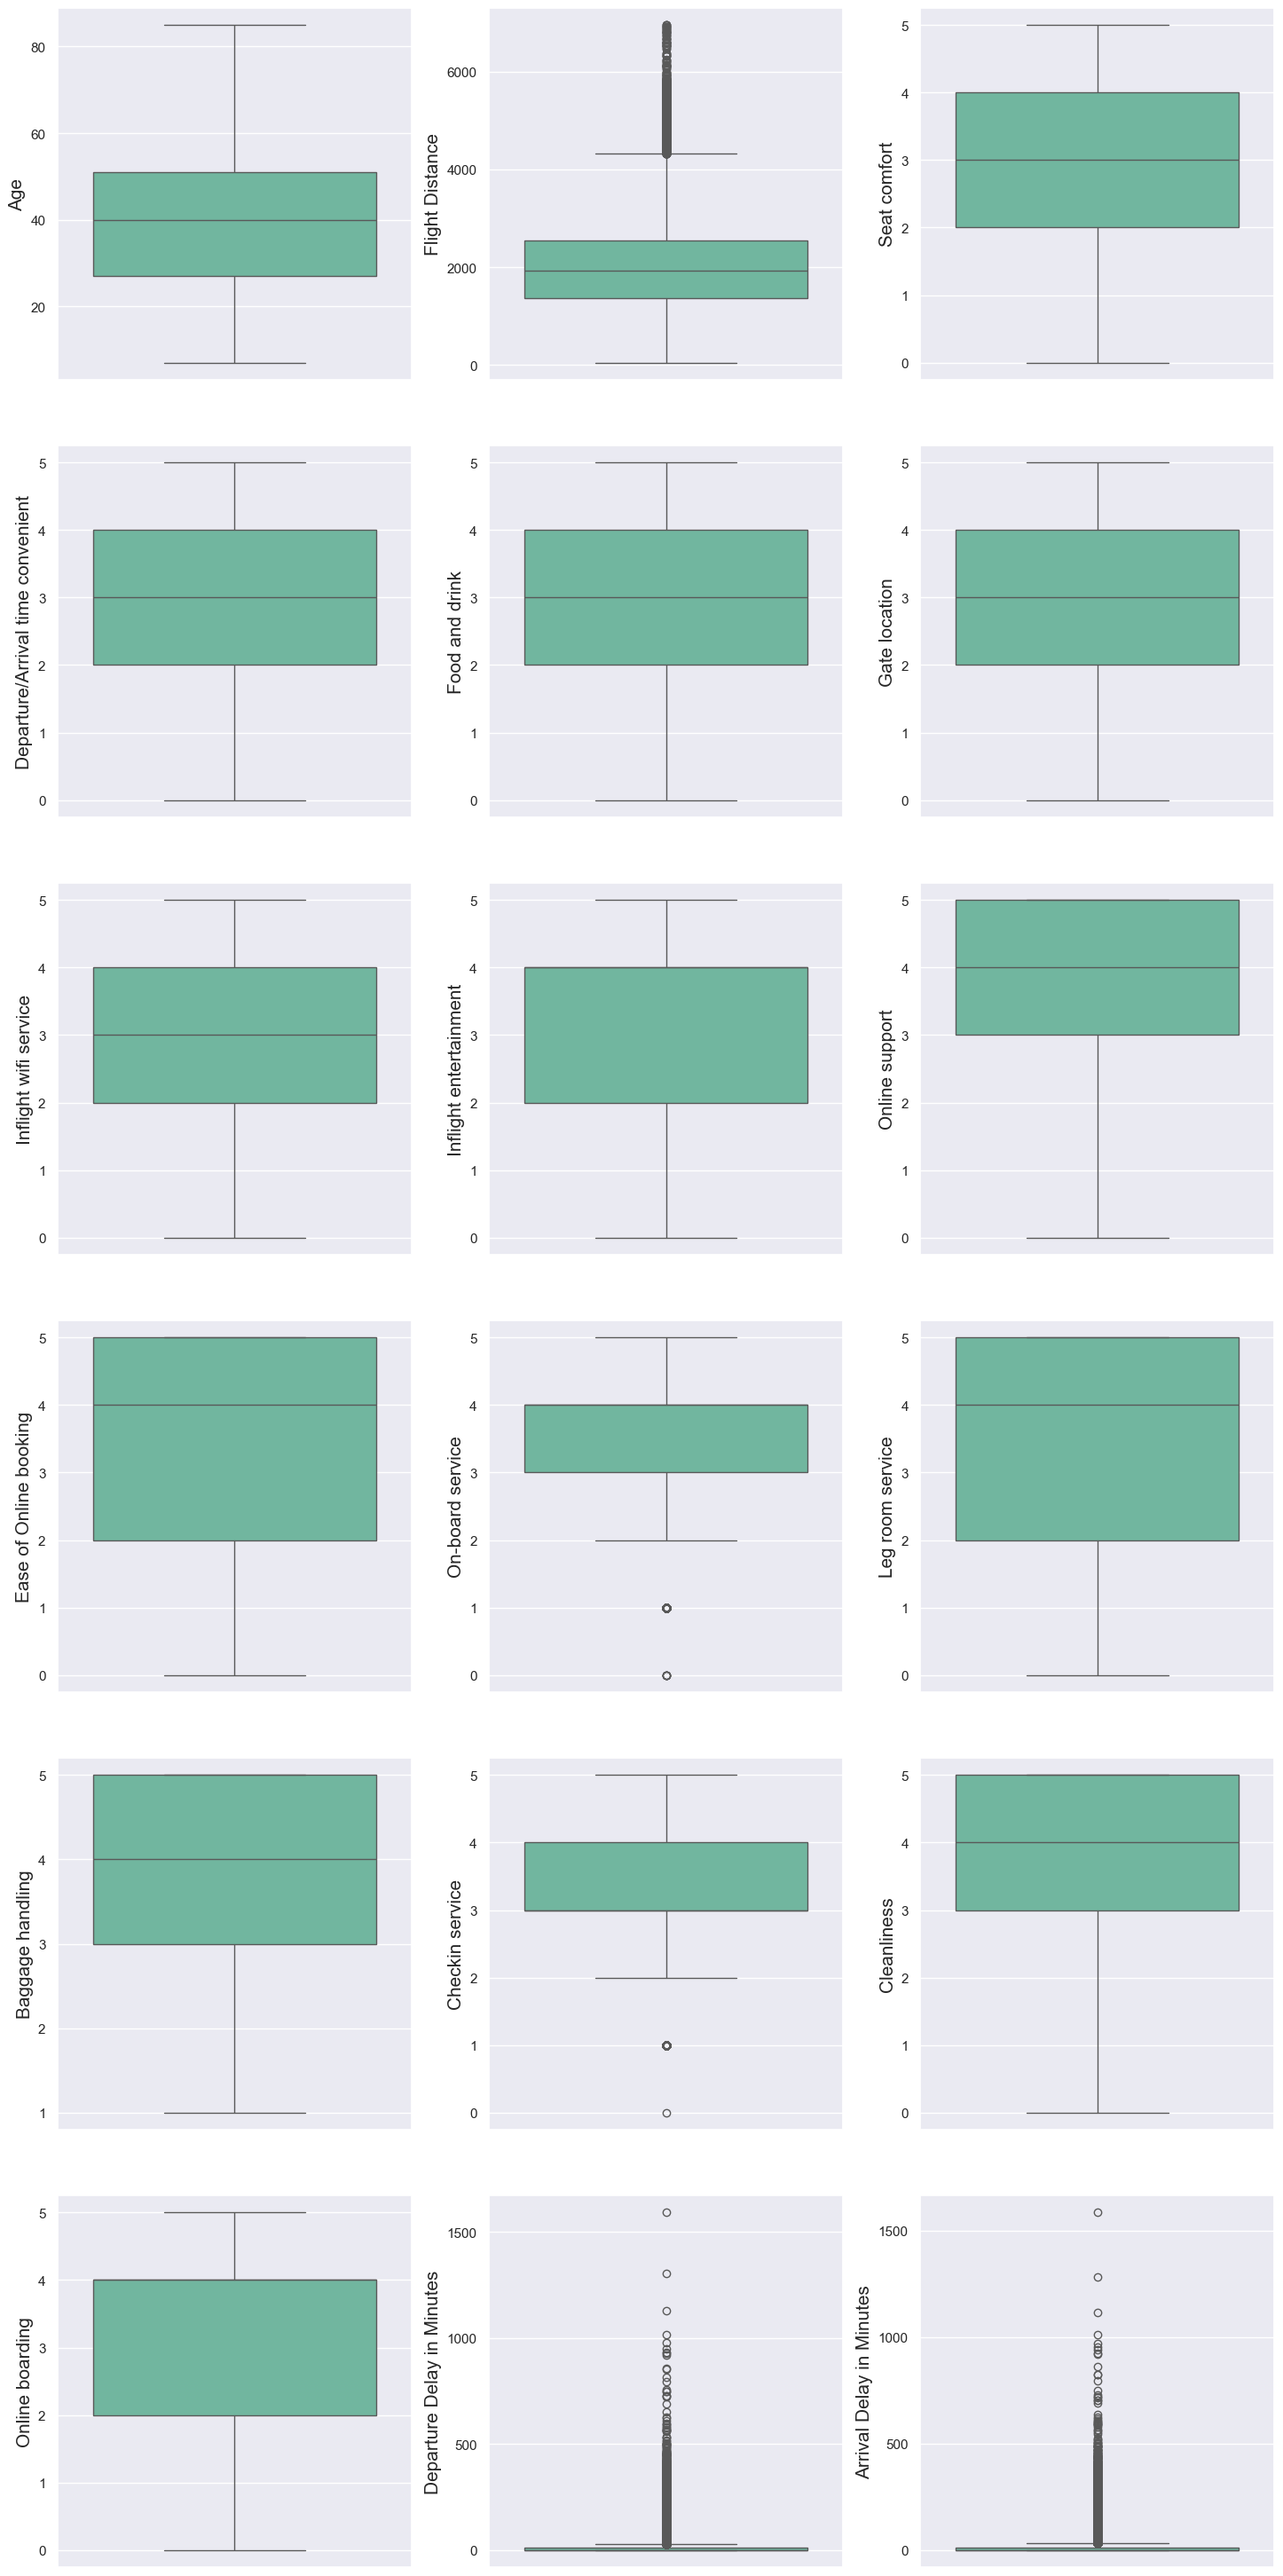

In [27]:
sns.set_theme(rc={
            "font.size":10,
            "axes.titlesize":10,
            "axes.labelsize":15},
             style="darkgrid",
            )
fig, axs = plt.subplots(6, 3, figsize=(15, 30))
fig.tight_layout(pad=3.0)

for f, ax in zip(numerical_cols, axs.ravel()):
    sns.set_theme(font_scale=2)
    ax= sns.boxplot(ax=ax, data=df, y=df[f], palette='BuGn')



**Observations**:

Flight distance, checkin service, Departure Delay in minutes, Arrival delay in minutes has some outliers

### Barplot representation of numerical features

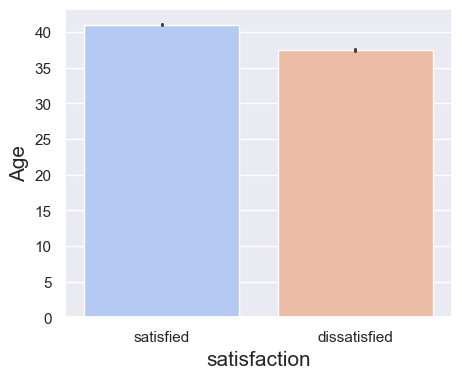

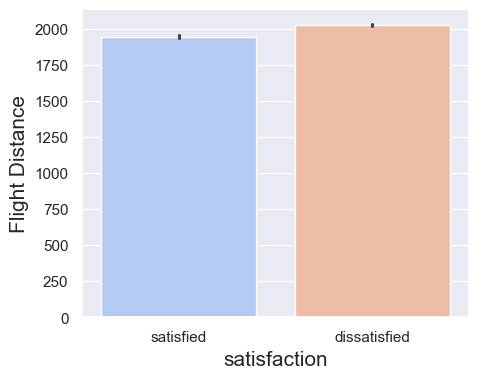

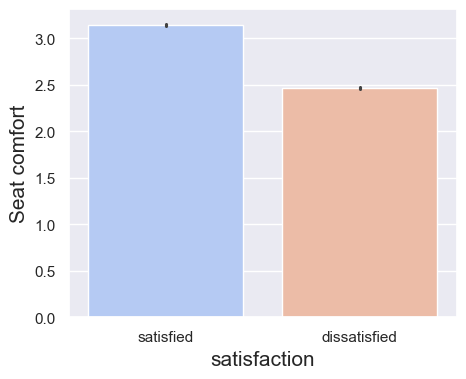

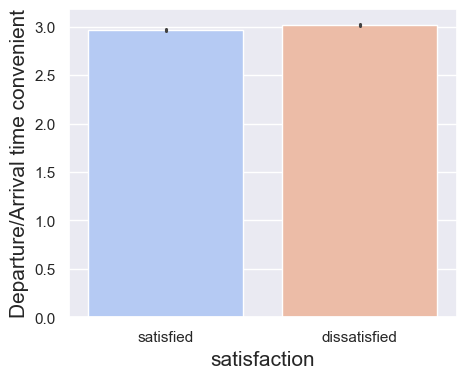

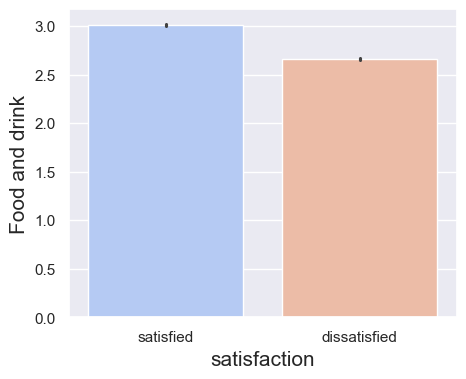

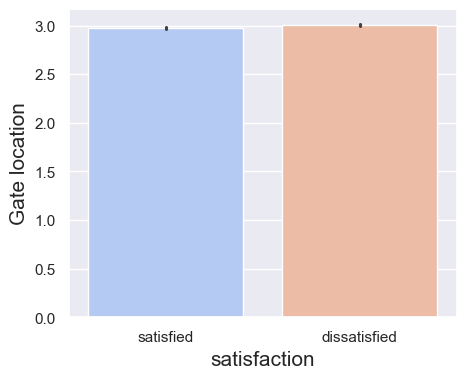

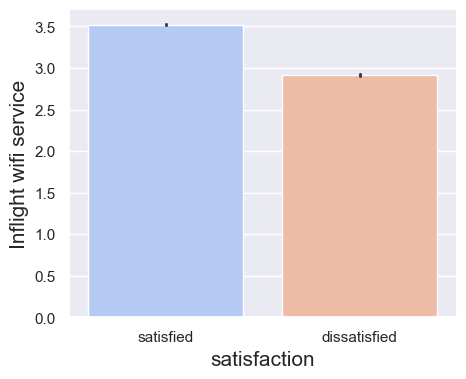

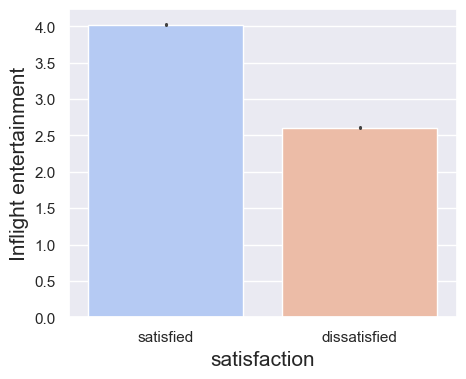

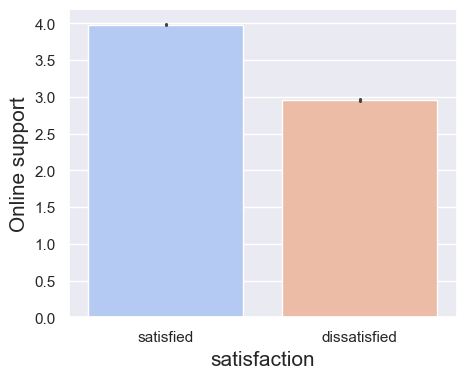

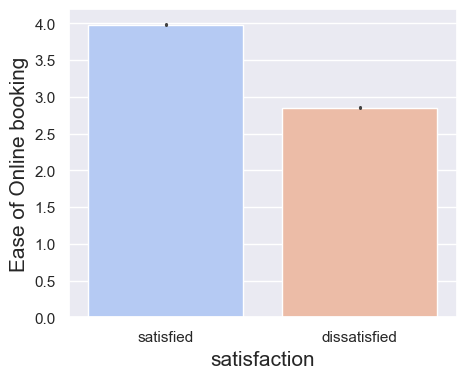

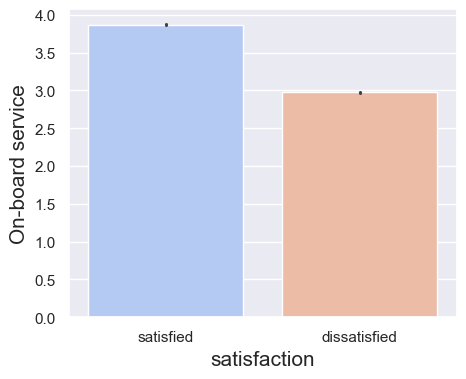

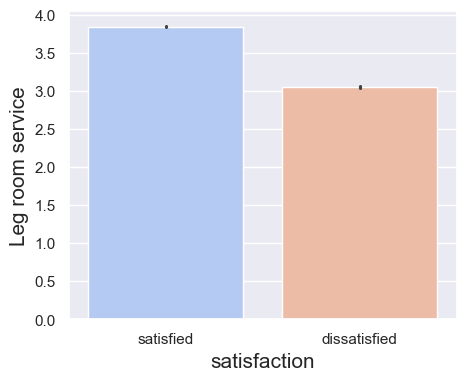

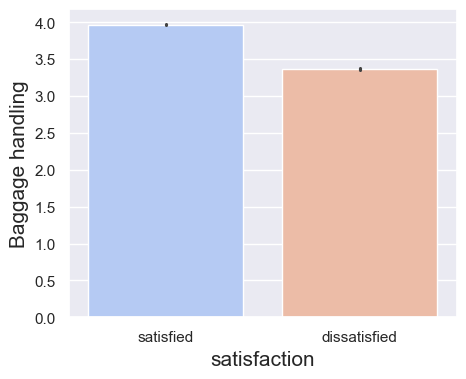

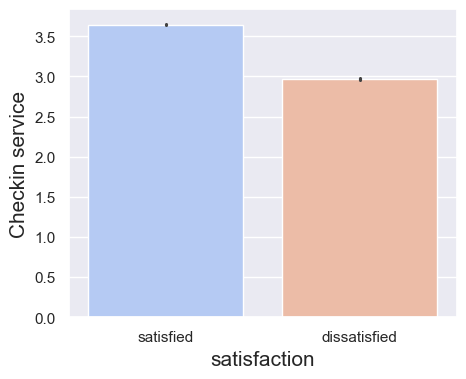

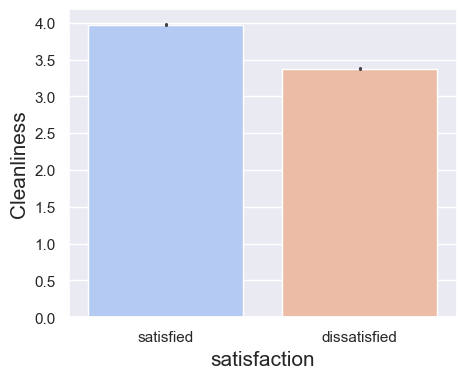

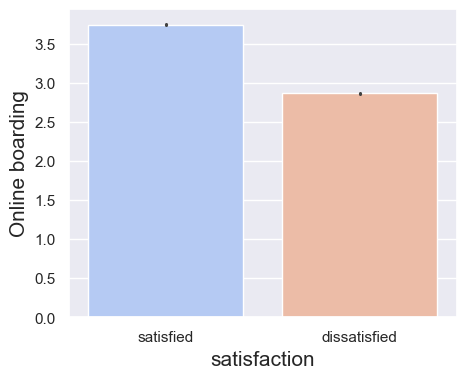

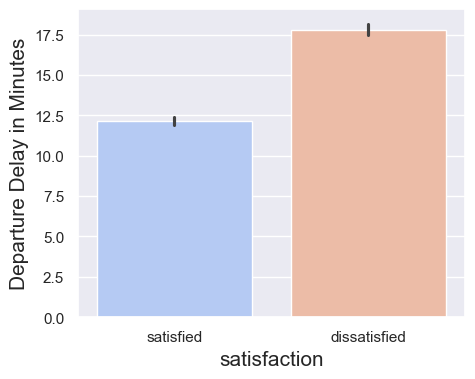

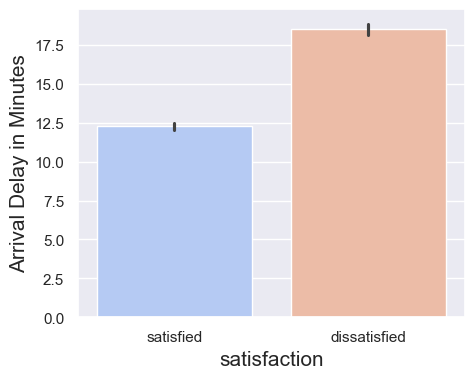

In [28]:
sns.set_theme(rc={'figure.figsize':(5,4),
            "font.size":10,
            "axes.titlesize":10,
            "axes.labelsize":15},
             style="darkgrid")

for col in numerical_cols:
    sns.barplot(data=df, x="satisfaction", y=col, palette='coolwarm')
    plt.show()

**Observations**:

- From above graphs,it is clear that the age and Gate location, does not play a huge role in flight satisfaction.


## EDA on Categorical Column

### Barplot representaion on Categoricol Column

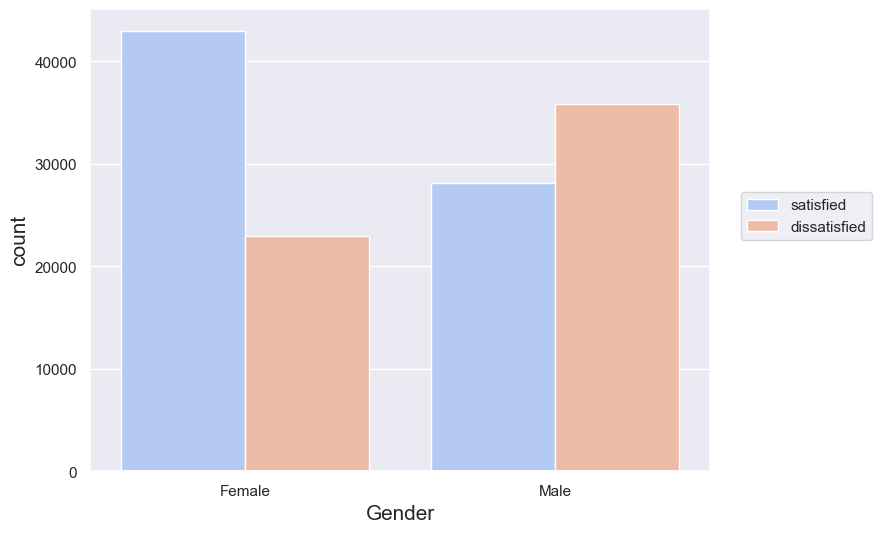

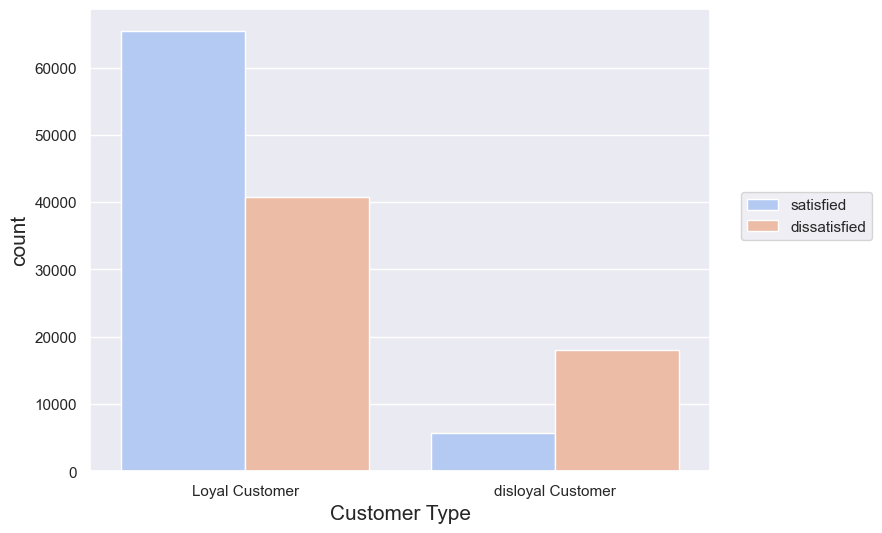

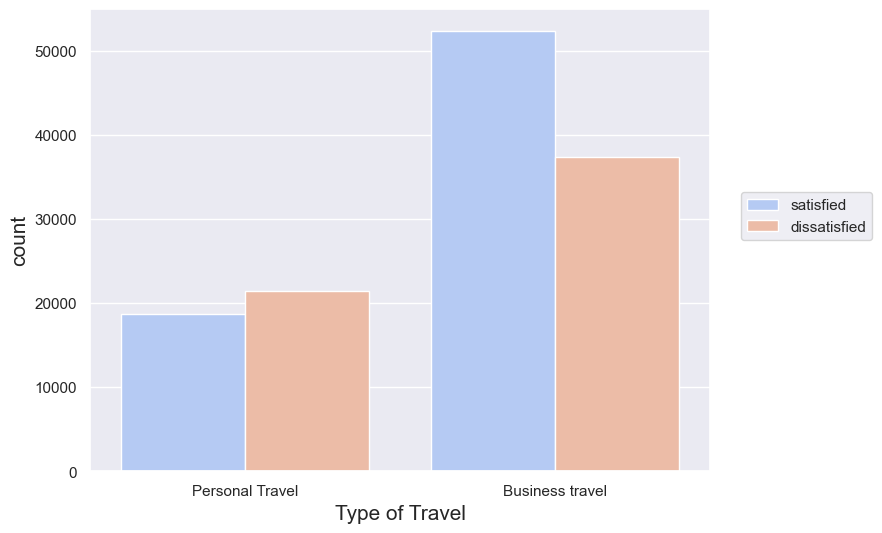

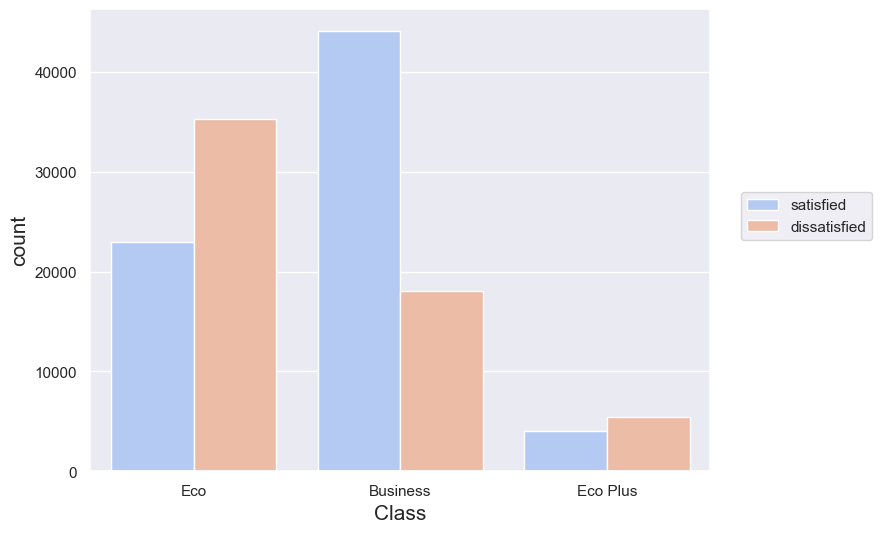

In [29]:
sns.set_theme(rc={'figure.figsize':(11.7,8.27),
            "font.size":10,
            "axes.titlesize":10,
            "axes.labelsize":15},
             style="darkgrid",
            )
for col in categorical_cols:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df,x=col, hue='satisfaction', palette='coolwarm')
    plt.legend(loc=(1.05,0.5))
    

**1. Class vs Satisfaction**

- **Business class passengers show the highest satisfaction**, significantly more satisfied than dissatisfied.
- **Economy class has more dissatisfied passengers**, suggesting service expectations may not be met.
- **Eco Plus has the smallest passenger base** and shows relatively higher dissatisfaction compared to satisfaction.

**2. Type of Travel vs Satisfaction**

- **Business travelers are predominantly satisfied**, indicating airline services align well with business traveler needs.
- **Personal travel passengers show higher dissatisfaction**, suggesting leisure travelers may be more price-sensitive or service-critical.

**3. Customer Type vs Satisfaction**

- **Loyal customers are highly satisfied**, indicating strong retention and positive experience among repeat passengers.
- **Disloyal customers are mostly dissatisfied**, suggesting poor experience may contribute to low customer retention.

**4. Gender vs Satisfaction**

- **Female passengers show higher satisfaction levels** compared to dissatisfaction.
- **Male passengers exhibit slightly higher dissatisfaction**, though the difference is not extremely large.
- Overall, **gender does not appear to strongly influence satisfaction compared to other variables**.

**Key Insight**

- **Customer loyalty, travel purpose, and travel class appear to be stronger drivers of satisfaction than demographic factors like gender.**

## Arrival Delay in Minutes VS Departure Delay in minutes.

In [30]:
df.groupby('satisfaction')['Arrival Delay in Minutes'].mean()

satisfaction
dissatisfied    18.504599
satisfied       12.268883
Name: Arrival Delay in Minutes, dtype: float64

<Axes: xlabel='Arrival Delay in Minutes', ylabel='Departure Delay in Minutes'>

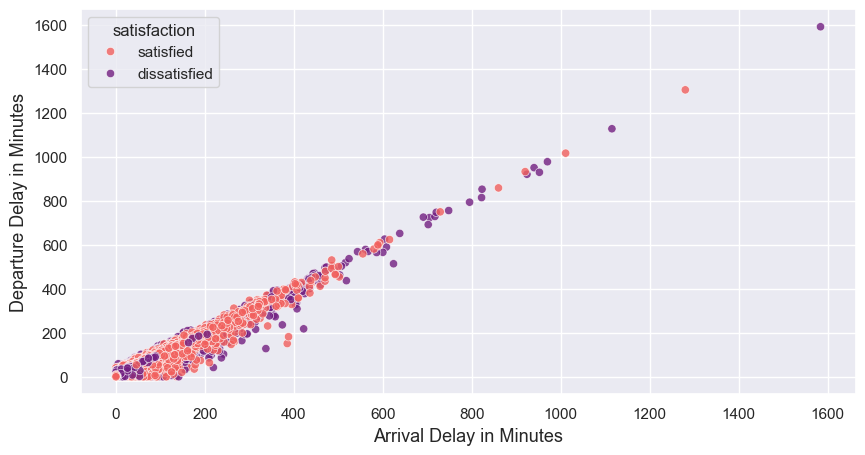

In [31]:
sns.set_theme(rc={
            "font.size":10,
            "axes.titlesize":10,
            "axes.labelsize":13},
             style="darkgrid")
plt.figure(figsize=(10, 5), dpi=100)
sns.scatterplot(data=df, x="Arrival Delay in Minutes", y= "Departure Delay in Minutes", hue='satisfaction', palette="magma_r",alpha=0.8)



**Observations**:

The arrival and departure delay seems to have a linear relationship, which makes complete sense! And well, there is 1 customer who was satisfied even after a delay of 1300 minutes!!


## Flight distance vs Departure Delay in Minutes

(0.0, 1000.0)

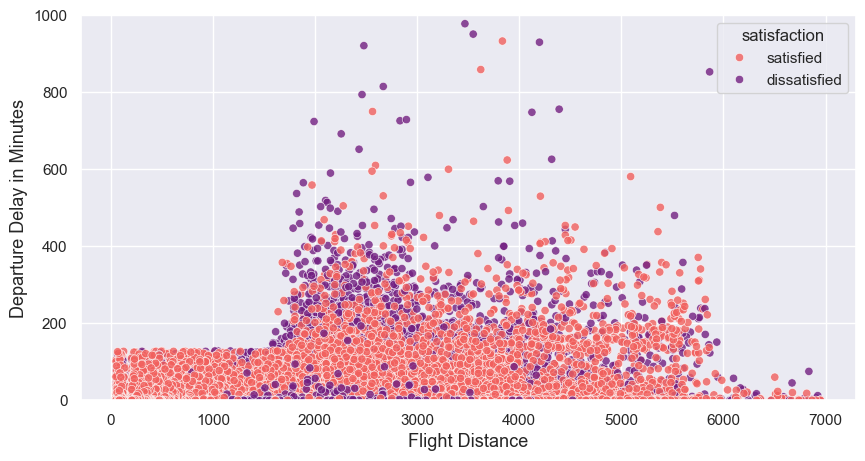

In [32]:
sns.set_theme(rc={
            "font.size":10,
            "axes.titlesize":10,
            "axes.labelsize":13},
             style="darkgrid")
plt.figure(figsize=(10, 5), dpi=100)
sns.scatterplot(data=df, x="Flight Distance", y= "Departure Delay in Minutes", hue='satisfaction', palette="magma_r",alpha=0.8)
plt.ylim(0,1000)

**Observations:**

- The most important takeaway here is the longer the flight distance,
most passengers are okay with flight delay in departure, which is
strance finding from this plot!
- So departure delay is less of a factor for a long distance flight,
comparitively, however, short distance travellers does not seem to be
excited about the departure delays, which also makes sense

## Age and Customer type

<Axes: xlabel='Age', ylabel='Count'>

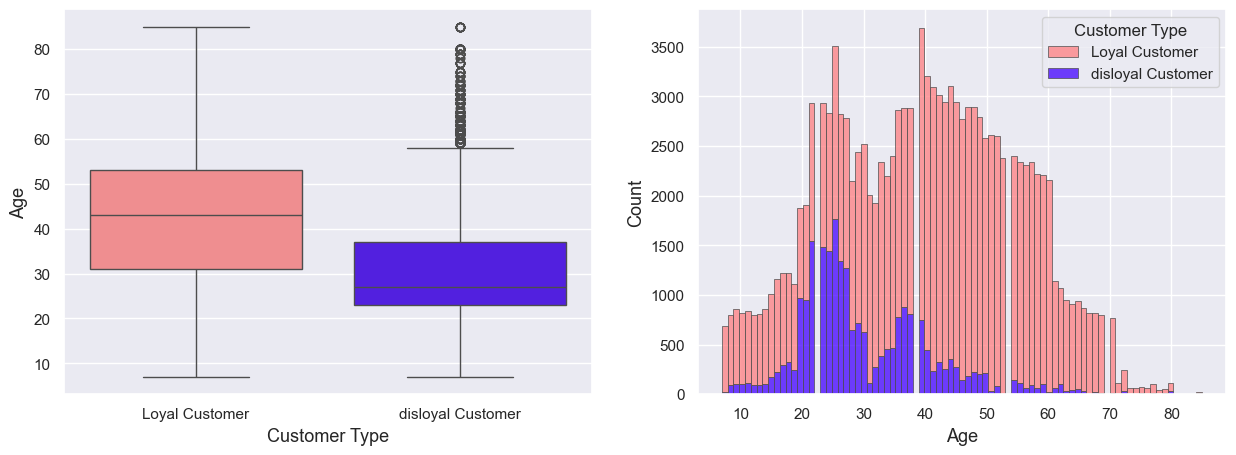

In [33]:
f, ax = plt.subplots(1,2, figsize=(15, 5))
sns.boxplot(data=df, x="Customer Type", y= "Age",palette = "gnuplot2_r", ax=ax[0])
sns.histplot(data=df, x="Age", hue="Customer Type", multiple="stack", palette = "gnuplot2_r",edgecolor = ".3", linewidth = .5, ax = ax[1])

**Observations:**

- From above we can conclude that most of the airline's regular
customers are between the ages of 30 and 50(their average age is
slightly above 40)
- The age range of non-regular customers is slightly smaller (from 25 to 40 years old, on average - a little less than 30).

## Age vs Class

<Axes: xlabel='Age', ylabel='Count'>

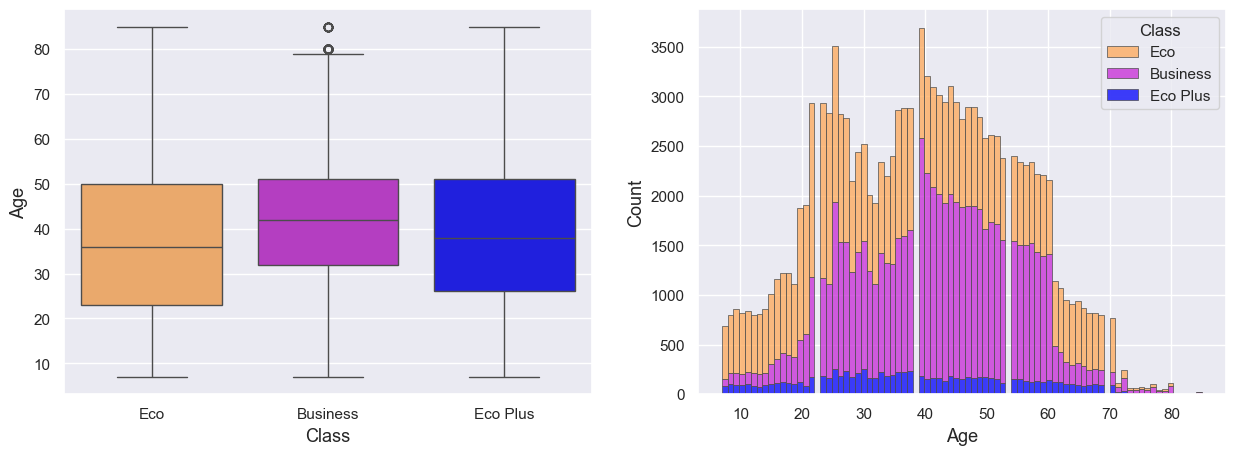

In [34]:
f, ax  =plt.subplots(1,2,figsize=(15,5))
sns.boxplot(data=df, x="Class", y="Age",palette = "gnuplot2_r", ax=ax[0])
sns.histplot(data=df, x="Age", hue="Class", multiple="stack", palette="gnuplot2_r",edgecolor = ".3", linewidth = .5, ax = ax[1])

It can be seen that, on average, the age range of those customers who travel in business class is the same (according to the previous box chart) as the age range of regular customers. Based on this observation, it can be assumed that regular customers mainly buy business and eco class for themselves.

<Axes: xlabel='Flight Distance', ylabel='Count'>

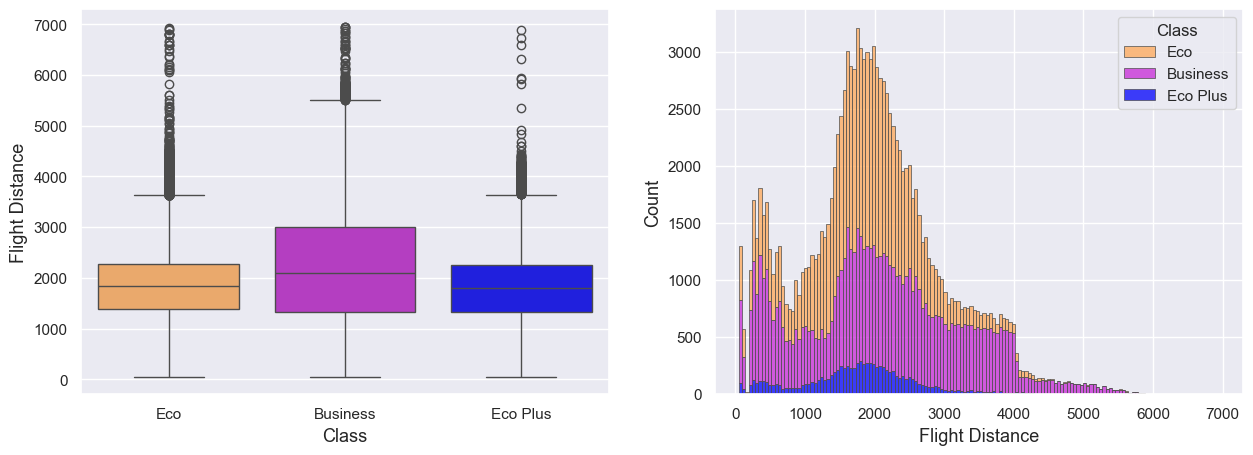

In [35]:
f, ax = plt.subplots(1, 2, figsize = (15,5))
sns.boxplot(x = "Class", y = "Flight Distance", palette = "gnuplot2_r", data = df, ax = ax[0])
sns.histplot(df, x = "Flight Distance", hue = "Class", multiple = "stack", palette = "gnuplot2_r", edgecolor = ".3", linewidth = .5, ax = ax[1])

Business class passengers generally travel longer distances, while Economy dominates passenger volume with most flights concentrated around 1500–2500 distance range, and Eco Plus has the smallest share.

<Axes: xlabel='Flight Distance', ylabel='Count'>

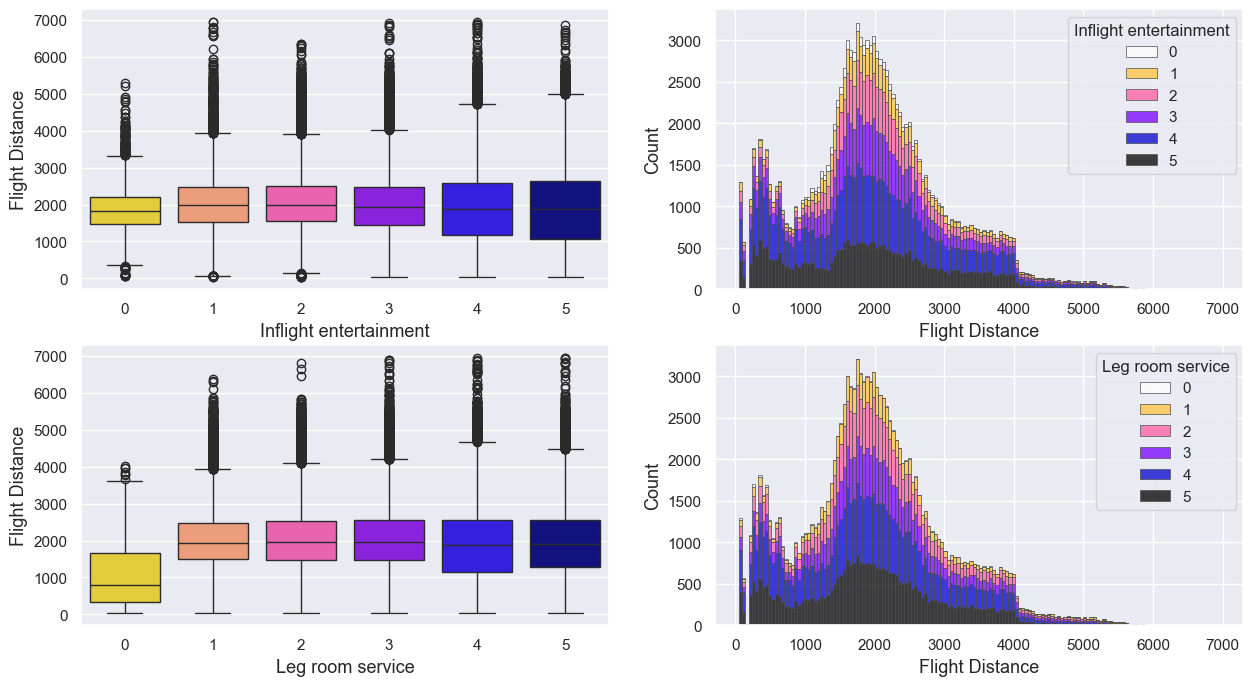

In [36]:
f,ax = plt.subplots(2,2, figsize=(15, 8))
sns.boxplot(x = "Inflight entertainment", y = "Flight Distance", palette = "gnuplot2_r", data = df, ax = ax[0, 0])
sns.histplot(df, x = "Flight Distance", hue = "Inflight entertainment", multiple = "stack", palette = "gnuplot2_r", edgecolor = ".3", linewidth = .5, ax = ax[0, 1])
sns.boxplot(x = "Leg room service", y = "Flight Distance", palette = "gnuplot2_r", data = df, ax = ax[1, 0])
sns.histplot(df, x = "Flight Distance", hue = "Leg room service", multiple = "stack", palette = "gnuplot2_r", edgecolor = ".3", linewidth = .5, ax = ax[1, 1])

**Observations**

- **Higher inflight entertainment ratings are slightly associated with longer flight distances**, suggesting better entertainment is offered on long-haul flights.
- **Legroom ratings tend to increase with flight distance**, indicating airlines provide better seating comfort on longer routes.
- Most flights across all ratings are **clustered around 1500–2500 distance range**, showing this is the most common flight distance segment.

## Multivariate Analysis

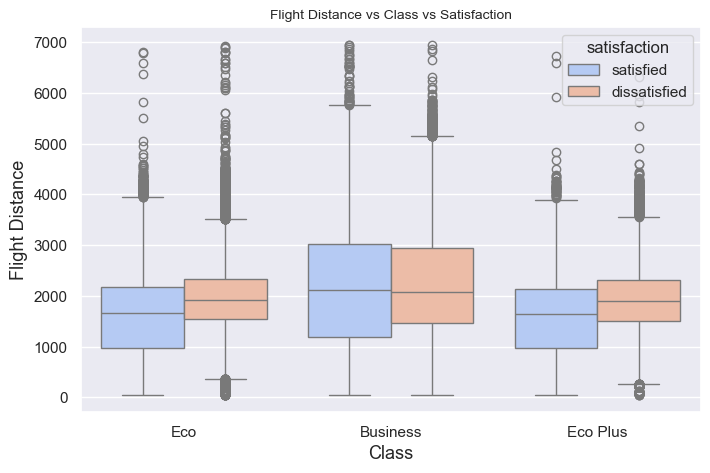

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Class',
    y='Flight Distance',
    hue='satisfaction',
    palette='coolwarm'
)

plt.title("Flight Distance vs Class vs Satisfaction")
plt.show()

- Business class passengers generally travel longer distances, showing a wider spread of flight distances compared to Economy and Eco Plus.

- Dissatisfied passengers tend to have slightly higher median flight distances across classes, suggesting longer flights may contribute to dissatisfaction.

# Actionable Insights
- **Business class passengers show the highest satisfaction**, suggesting premium services are effectively meeting expectations; improving Economy services could reduce dissatisfaction.
- **Loyal customers are significantly more satisfied**, indicating strong customer retention potential; focusing on loyalty programs can further increase repeat customers.
- **Service-related factors (seat comfort, inflight entertainment, legroom, cleanliness)** strongly influence satisfaction, so improving these areas can directly enhance customer experience.
- **Most flights are medium-distance (1500–2500)**, so optimizing services for this segment will impact the majority of passengers.
- **Flight delays show potential impact on dissatisfaction**, highlighting the importance of operational efficiency and schedule reliability.